## The impostor on hunt with ANN & GRU

#### Competition summary

The main task of this competition is to detect fake texts in a given dataset. Each data sample contains two texts - one real and one fake. The data used in this Challenge come from The Messenger journal. Importantly, both texts in each sample - real (optimal for the recipient, as close as possible to the hidden original text) and fake (more or much more distant from the hidden original text)

#### Deeplearning model I'm going use in this project

### 1 .ANN
An Artificial Neural Network is a computational model inspired by the human brain. It consists of layers of interconnected nodes (neurons) that process input data and learn patterns to make predictions or classifications



### 2. GRU

GRU is a simplification of the LSTM cell that performs similarly well while being faster to train. It has a single update gate controller that manages both the forget and input gates. Whenever one is open, the other is closed. There is no output gate. The reset gate controls which part of the previous state is shown to the main layer. The resulting model is simpler than standard LSTM models. GRUs have fewer parameters and thus may train a bit faster or need less data to generalize.


### Load python libraries

In [1]:
import warnings
warnings.simplefilter("ignore")

In [2]:
# import needed libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import one_hot
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow import keras
from keras.utils import pad_sequences

from keras.models import Sequential, Model
from keras.layers import Dense, Embedding
from keras.layers import SimpleRNN, LSTM
from keras import initializers

2025-08-15 09:20:51.381869: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755249651.728353      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755249651.828414      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


#### Python libraries has been successfull loaded,

So we are ready to load the dataset has you'll see the dataset are a different test files that need to be process then load has one dataset, so we'll need to run some few python code.

## Load the dataset


In [3]:
df = pd.read_csv(r"/kaggle/input/fake-or-real-the-impostor-hunt/data/train.csv")

In [4]:
foldr_path =  "/kaggle/input/fake-or-real-the-impostor-hunt/data/test"

In [5]:
import os

# Function to build the path
def path(text_id, article_id):
    return os.path.join("/kaggle/input/fake-or-real-the-impostor-hunt/data/test",
                        f"article_{article_id}", f"file_{text_id}.txt")

# Function to read text from a file path
def read_text(foldr_path):
    if os.path.exists(foldr_path):
        with open(foldr_path, 'r', encoding='utf-8') as f:
            return f.read()
    else:
        return ""  # or None, if file does not exist

# Your dataframe transformations:
df['article'] = df['id'].apply(lambda x: str(x).zfill(4))
df['fake_text_id'] = df['real_text_id'].apply(lambda x: 1 if x == 2 else 2)

df['real_text_file'] = df[['real_text_id', 'article']].apply(lambda x: path(x['real_text_id'], x['article']), axis=1)
df['fake_text_file'] = df[['fake_text_id', 'article']].apply(lambda x: path(x['fake_text_id'], x['article']), axis=1)

# Apply the read_text function here instead of 'folder_path'
df['real_text'] = df['real_text_file'].apply(read_text)
df['fake_text'] = df['fake_text_file'].apply(read_text)

df_real = df[['article', 'real_text']].copy()
df_real.columns = ['article', 'text']
df_real['label'] = 0

df_fake = df[['article', 'fake_text']].copy()
df_fake.columns = ['article', 'text']
df_fake['label'] = 1

data = pd.concat([df_real, df_fake], ignore_index=True)


In [6]:
data.head(5)

,article,text,label
0,0000,"""Music"" Music music music Music music Music mu...",0
1,0001,SN 1987A provides valuable insights as newer o...,0
2,0002,This research aimed to understand how star sha...,0
3,0003,"greek translation :\nvazhi (megaCAM), territor...",0
4,0004,XClass is software tool that helps astronomers...,0


Add text lengh size column to our dataset for farther analysis 

In [7]:
data['text_size'] = data['text'].apply(len).astype('int')
data = data.sample(frac=1, random_state=42).reset_index(drop=True)
data.head()

,article,text,label,text_size
0,0080,underground\nIs there more variation between h...,1,1604
1,0085,Dark matter plays a crucial role shaping our u...,1,1378
2,0016,During their long mission planning phase they ...,1,1118
3,0065,egorie test has been developed using a unique ...,0,1797
4,0006,The way information flows through 4MOST follow...,1,1053


In [8]:
data.duplicated().sum()

0

Exploratory data analysis

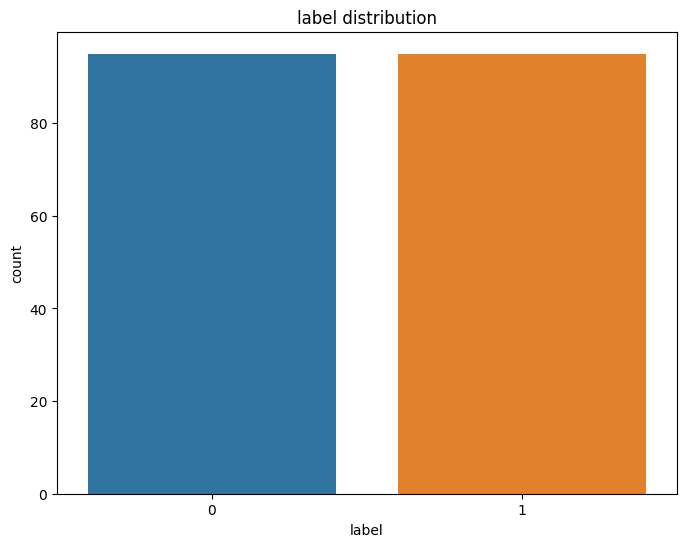

In [9]:
plt.figure(figsize=(8,6))
sns.countplot(data = data, x='label'  )
plt.title("label distribution")
plt.show()

In [10]:
fake = data[data['label']==1]
real = data[data['label']==0]

print(f"Shape of fake messages distributions: {fake.shape}")
print(f"Shape of real messages distributions: {real.shape}")

Shape of fake messages distributions: (95, 4)
Shape of real messages distributions: (95, 4)


In [11]:
pd.concat([fake.text_size.describe(), real.text_size.describe()], axis = 1)

,text_size,text_size
count,95.000000,95.000000
mean,1227.221053,1196.147368
std,701.282809,529.135464
min,56.000000,10.000000
25%,864.000000,879.500000
50%,1173.000000,1157.000000
75%,1472.000000,1513.500000
max,5185.000000,3255.000000


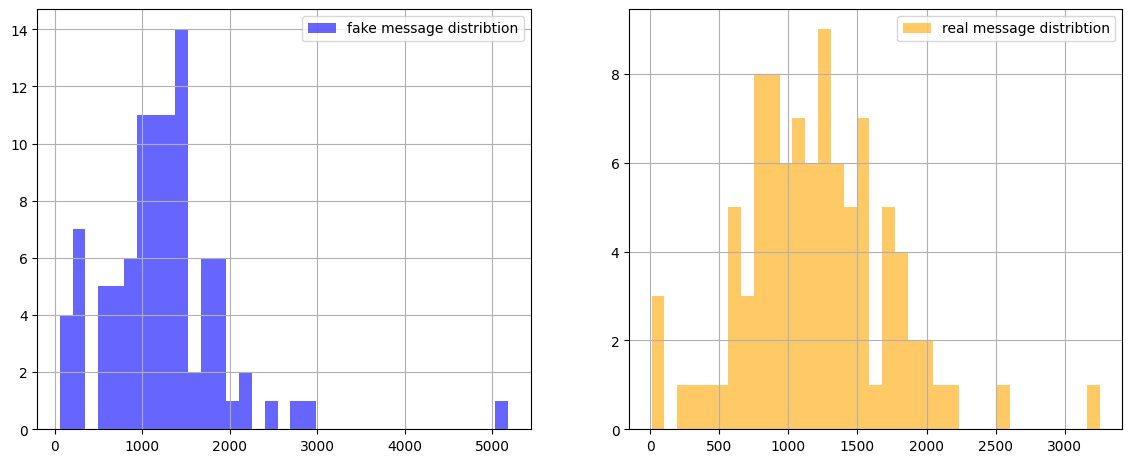

In [12]:
plt.figure(figsize=(14, 12))

plt.subplot(2, 2, 1)
fake['text_size'].hist(bins=35, color='blue', alpha=0.6, label="fake message distribtion")
plt.legend()

plt.subplot(2, 2, 2)
real['text_size'].hist(bins=35, color='orange', alpha=0.6, label="real message distribtion")
plt.legend()

In [13]:
#!pip install wordcloud

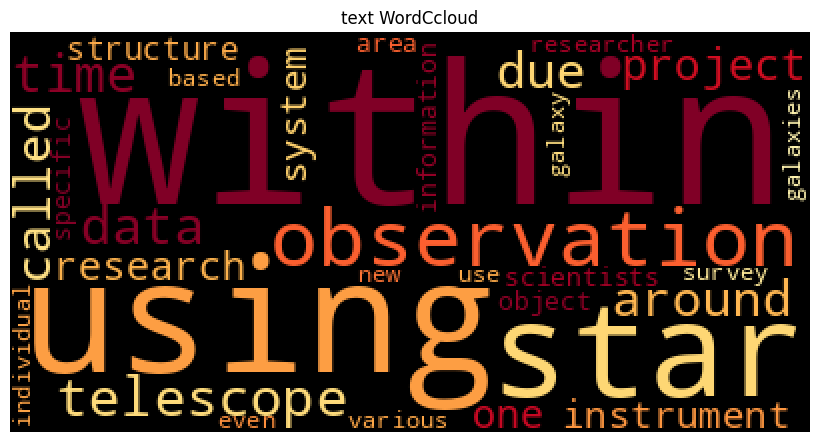

In [14]:
# import stopwords and Wordcloud
from wordcloud import STOPWORDS, WordCloud
# Define stopwords
stop_words = stop_words = set(STOPWORDS)

# Convert comments to a list, filter stopwords, and join
def preprocess_comments(comment_series):
    return ' '.join(
        word for comment in comment_series.dropna().tolist()
        for word in comment.split() if word.lower() not in stop_words
    )

# Process comments
pos_text = preprocess_comments(data['text'])

# Generate WordClouds
wordcloud_pos = WordCloud(width=400, height=200, background_color='black',
                          stopwords=stop_words, colormap='YlOrRd', max_words=200,
                          min_font_size=10).generate(pos_text)

# Plot WordClouds
plt.figure(figsize=(8, 6), facecolor=None)
plt.title('text WordCcloud')
plt.imshow(wordcloud_pos)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

## Text processing 

The Python `re` module provides functionalities for working with regular expressions, a powerful tool for text processing. It allows for searching, matching, and manipulating strings based on defined patterns.

In [15]:
import string
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

stemmer = PorterStemmer()
corpus = []

def preprocess_text(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[^a-zA-Z]', ' ', text)
    text = text.lower()
    text = re.sub('\n', ' ', text)
    text = re.sub('\w*\d\w*', '', text)
    words = text.split()
    words = [stemmer.stem(word) for word in words if word not in stop_words]
    return ' '.join(words)

# Apply to the dataset
data['cleaned_text'] = data['text'].apply(preprocess_text)
# One-hot encoding
vocab_size = 10000
one_hot_pre = [one_hot(text, vocab_size) for text in data['cleaned_text']]

# Padding sequences
sent_length = 500  # 5000 is very long; 500 is more typical
embedded_docs = pad_sequences(one_hot_pre, padding='pre', maxlen=sent_length)

print(embedded_docs)


[[   0    0    0 ... 9045 6683 1334]
 [   0    0    0 ... 4734 1973 7543]
 [   0    0    0 ... 7944 2150  942]
 ...
 [   0    0    0 ... 4147 5308  602]
 [   0    0    0 ... 6269 3468 4444]
 [   0    0    0 ... 2519 6622 6958]]


### Train test split data for machine model preparation

In [16]:
len(embedded_docs)

190

In [17]:
x_final = np.array(embedded_docs)
y_final = data['label']

X_train, X_test, y_train, y_test = train_test_split(x_final, y_final, test_size=0.3, random_state=42,stratify = y_final)



In [18]:
max_features = 10000 # This is used in loading the data, picks the most common (max_features) words
maxlen = 5000  # maximum length of a sequence - truncate after this
batch_size = 256
# data preprocessing
X_train = pad_sequences(X_train, maxlen=maxlen)
X_test = pad_sequences(X_test, maxlen=maxlen)
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)


X_train shape: (133, 5000)
X_test shape: (57, 5000)


# 1. ANN Model

In [19]:
from tensorflow.keras.layers import Embedding,GRU, Dropout, Dense
from tensorflow.keras.optimizers import Adam

model = Sequential()

# Input layer
model.add(Dense(units=128, activation='relu', input_shape=(X_train.shape[1],)))

# Hidden layers
model.add(Dropout(0.3))
model.add(Dense(units=64, activation='relu'))
model.add(Dropout(0.3))

# Output layer for binary classification
model.add(Dense(units=1, activation='sigmoid'))

I0000 00:00:1755249673.525518      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1755249673.526296      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,449 (2.47 MB)

 Trainable params: 648,449 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=1)

Epoch 1/50


I0000 00:00:1755249676.896558      63 service.cc:148] XLA service 0x7e0c34004c40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1755249676.898008      63 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1755249676.898035      63 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1755249677.236361      63 cuda_dnn.cc:529] Loaded cuDNN version 90300


1/4 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step - accuracy: 0.4375 - loss: 421.4009

I0000 00:00:1755249678.854686      63 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 630ms/step - accuracy: 0.4464 - loss: 486.4444 - val_accuracy: 0.4815 - val_loss: 326.2307
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5898 - loss: 361.9654 - val_accuracy: 0.5185 - val_loss: 122.4230
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4841 - loss: 449.5505 - val_accuracy: 0.5185 - val_loss: 194.1967
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5936 - loss: 215.8985 - val_accuracy: 0.4444 - val_loss: 233.7253
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5626 - loss: 241.1298 - val_accuracy: 0.4815 - val_loss: 114.7856
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6342 - loss: 153.7783 - val_accuracy: 0.5926 - val_loss: 87.1564
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6604 - loss: 139.8548 - val_accuracy: 0.6296 - val_loss: 93.2113
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5777 - loss: 148.8121 - val_accuracy: 0.4815 -

## ANN model evaluation

In [22]:
from sklearn.metrics import classification_report

y_train_preds = model.predict(X_train)
y_train_labels = (y_train_preds > 0.5).astype(int)  # for binary classification
print('Classification evaluation')
print(classification_report(y_train, y_train_labels))

print('The loss and Accuracy evaluation')
loss, accuracy = model.evaluate(X_train, y_train)
print(f'Train accuracy: {accuracy * 100:.2f}%')
print(f'Train loss: {loss * 100:.2f}')


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Classification evaluation
              precision    recall  f1-score   support

           0       0.89      0.83      0.86        66
           1       0.85      0.90      0.87        67

    accuracy                           0.86       133
   macro avg       0.87      0.86      0.86       133
weighted avg       0.87      0.86      0.86       133

The loss and Accuracy evaluation
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9137 - loss: 14.0569
Train accuracy: 86.47%
Train loss: 2823.67


# 2. GRU Model

In [23]:
# Hyperparameters (Make sure to define these before use)
embedding_vector_features = 1000

# Model definition
model1 = Sequential()
model1.add(Embedding(vocab_size, embedding_vector_features, input_shape=(X_train.shape[1:])))  # maximum length of a sequence - truncate after this))  # Embedding layer
model1.add(GRU(256))  # GRU layer with 128 units
model1.add(Dropout(0.2))  # Dropout for regularization
model1.add(Dense(128, activation='relu'))  # Dense layer with ReLU activation
model1.add(Dropout(0.2))  # Dropout for regularization
model1.add(Dense(1, activation='sigmoid'))  # Output layer with softmax activation for multi-class (2 classes)

# Compile the model
rmsprop = Adam(learning_rate=0.005)
model1.compile(loss='binary_crossentropy', optimizer=rmsprop, metrics=['accuracy'])

# Fit the model
model1.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=5,
    batch_size=30,
    verbose=1)

Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 502ms/step - accuracy: 0.4654 - loss: 0.6999 - val_accuracy: 0.4211 - val_loss: 0.7087
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 412ms/step - accuracy: 0.8957 - loss: 0.4799 - val_accuracy: 0.3860 - val_loss: 2.0260
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 414ms/step - accuracy: 0.9961 - loss: 0.0269 - val_accuracy: 0.2982 - val_loss: 5.0285
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 417ms/step - accuracy: 0.9857 - loss: 0.0311 - val_accuracy: 0.3684 - val_loss: 4.4767
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 420ms/step - accuracy: 0.9724 - loss: 0.0814 - val_accuracy: 0.3684 - val_loss: 4.9792


## GRU model evaluation matrix

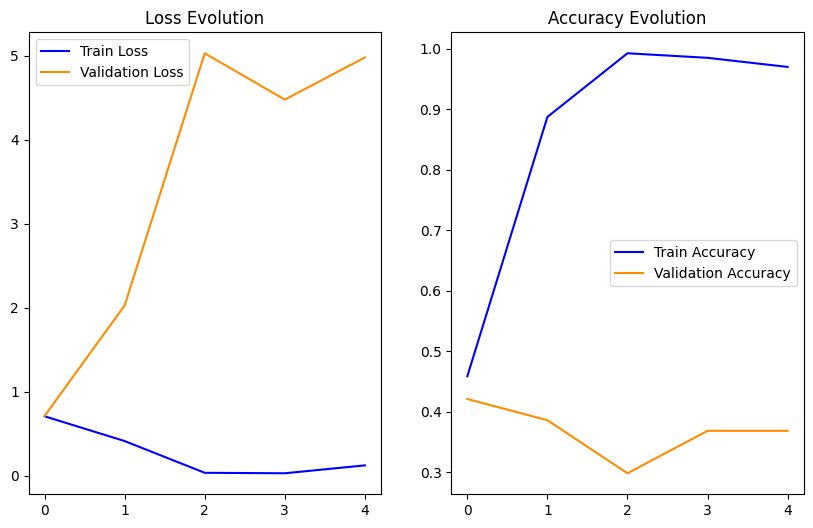

In [24]:
plt.figure(figsize=(10,6))

# Plotting the training and validation loss
plt.subplot(1, 2, 1)
plt.plot(model1.history.history['loss'], label='Train Loss', color='blue')
plt.plot(model1.history.history['val_loss'], label='Validation Loss', color='darkorange')
plt.legend()
plt.title('Loss Evolution')

# Plotting the training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(model1.history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(model1.history.history['val_accuracy'], label='Validation Accuracy', color='darkorange')
plt.legend()
plt.title('Accuracy Evolution')

plt.show()

In [25]:
loss, accuracy = model1.evaluate(X_train, y_train)
print(f'Train accuracy: {accuracy * 100:.2f}%')
print(f'Train loss: {loss * 100:.2f}%')

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step - accuracy: 1.0000 - loss: 8.9588e-05
Train accuracy: 100.00%
Train loss: 0.02%


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step


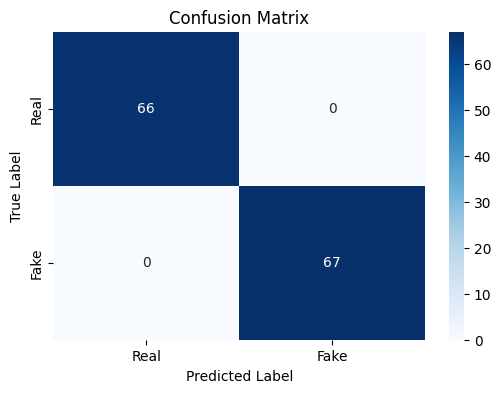

In [26]:
from sklearn.metrics import classification_report

y_train_preds = model1.predict(X_train)
y_train_labels = (y_train_preds > 0.5).astype(int)  # for binary classification

from sklearn.metrics import confusion_matrix, roc_curve, auc

cm = confusion_matrix(y_train, y_train_labels)

# Plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()



## Submission of result

In [27]:
### Data preparation for submission
test_path = '/kaggle/input/fake-or-real-the-impostor-hunt/data/test'

# Initialize list to hold test data
test_data = []

# Loop through each article folder
for folder in sorted(os.listdir(test_path)):
    folder_path = os.path.join(test_path, folder)
    if os.path.isdir(folder_path):
        for file_id in ["1", "2"]:
            file_name = f"file_{file_id}.txt"
            file_path = os.path.join(folder_path, file_name)

            try:
                with open(file_path, 'r') as f:
                    text = f.read()
                test_data.append({
                    "folder": folder,
                    "file_id": file_id,
                    "text": text
                })
            except FileNotFoundError:
                print(f"File not found: {file_path}")

# Create DataFrame
test_df = pd.DataFrame(test_data)

# Save for reference
test_df.to_csv("test_individual_texts.csv", index=False)

print("✅ Done! Test data read like train format.")
print(test_df.head())

✅ Done! Test data read like train format.
         folder file_id                                               text
0  article_0000       1  "Music" Music music music Music music Music mu...
1  article_0000       2  Since its launch on Paranal observatory's Very...
2  article_0001       1  underground exploration on SN's birth has prov...
3  article_0001       2  SN 1987A provides valuable insights as newer o...
4  article_0002       1  This research aimed to understand how star sha...


In [28]:
# Preprocess test data
test_df['text_clean'] = test_df['text'].astype(str).apply(preprocess_text)

# One-hot encode
X_test = [one_hot(text, vocab_size) for text in test_df['text_clean']]

# Pad sequences
X_test_padded = pad_sequences(X_test, padding='pre', maxlen=sent_length)

# Predict with GRU model
y_test_preds = model1.predict(X_test_padded)

# Convert predictions to binary labels
y_test_labels = (y_test_preds > 0.5).astype(int).flatten()

# Add predictions to DataFrame
test_df['prediction'] = y_test_labels


67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


In [29]:
# Extract numeric ID from folder name
test_df['id'] = test_df['folder'].str.extract(r'(\d+)').astype(int)

# Decide which text is real based on predicted labels:
# For each pair (1 and 2), choose the one predicted as 'Real' (1), or default to 1
submission_rows = []
for i in range(0, len(test_df), 2):
    id_val = test_df.iloc[i]['id']
    pred1 = test_df.iloc[i]['prediction']
    pred2 = test_df.iloc[i + 1]['prediction']

    # Which one is predicted as real?
    if pred1 == 1 and pred2 != 1:
        real_text = 1
    elif pred2 == 1 and pred1 != 1:
        real_text = 2
    else:
        # If both are Real or both are Fake, pick the first
        real_text = 1

    submission_rows.append({'id': id_val, 'real_text_id': real_text})

# Create DataFrame and save
submission_df = pd.DataFrame(submission_rows)
# Save to CSV
submission_df.to_csv('submission.csv', index=False)

In [30]:
submission_df.head(10)

,id,real_text_id
0,0,2
1,1,2
2,2,2
3,3,1
4,4,1
5,5,2
6,6,1
7,7,1
8,8,1
9,9,1


## Summary:

 Both ANN and GRU models were trained and evaluated on a dataset of text articles to classify them as real or fake. The models were preprocessed using one-hot encoding and padding. The ANN model achieved a training accuracy of 78%, while the GRU model achieved a training accuracy of 99%.


## Conclusion: 

Both ANN and GRU models performed well on the training data. However, further evaluation on a separate test set is needed to assess their generalization performance and determine the best model for deployment.

